# Import Libraries

In [3]:
!pip install wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip install imblearn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Load some necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from wordcloud import WordCloud

from pathlib import Path
import sys

root = Path.cwd().resolve()
for parent in [root] + list(root.parents):
    if (parent / "ml_engine").exists():
        sys.path.insert(0, str(parent))
        break
else:
    sys.path.insert(0, str(root))

from ml_engine.preprocessing import load_data, inspect_data

In [3]:
# Consistent plot style throughout
sns.set_style("whitegrid")
sns.set_palette("Set2")
FRAUD_PALETTE = {0: "#4C9BE8", 1: "#E84C4C"}
FIG_DPI = 120

In [4]:
warnings.filterwarnings("ignore")

# Load the datasets

In [6]:
# Load the medical claims data
benf_df, inpatient_df, outpatient_df, labels_df = load_data(
    '../data/Train_Beneficiarydata-1542865627584.csv',
    '../data/Train_Inpatientdata-1542865627584.csv',
    '../data/Train_Outpatientdata-1542865627584.csv',
    '../data/Train-1542865627584.csv'
)

# EDA and Data Preprocessing

## Inspecting the datasets

In [7]:
inspect_data(benf_df, "Beneficiary Data")


DATASET: Beneficiary Data

Shape:
(138556, 25)

Columns:
['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']

Data Types:
BeneID                             object
DOB                                object
DOD                                object
Gender                              int64
Race                                int64
RenalDiseaseIndicator              object
State                               int64
County                              int64
NoOfMonths_PartACov                 int64
NoOfMonths_Par

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200


In [8]:
inspect_data(inpatient_df, "Inpatient Data")


DATASET: Inpatient Data

Shape:
(40474, 30)

Columns:
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6']

Data Types:
BeneID                     object
ClaimID                    object
ClaimStartDt               object
ClaimEndDt                 object
Provider                   object
InscClaimAmtReimbursed      int64
AttendingPhysician         object
OperatingPhysician         object
OtherPhysician             object
AdmissionDt            

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [9]:
inspect_data(outpatient_df, "Outpatient Data")


DATASET: Outpatient Data

Shape:
(517737, 27)

Columns:
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid', 'ClmAdmitDiagnosisCode']

Data Types:
BeneID                     object
ClaimID                    object
ClaimStartDt               object
ClaimEndDt                 object
Provider                   object
InscClaimAmtReimbursed      int64
AttendingPhysician         object
OperatingPhysician         object
OtherPhysician             object
ClmDiagnosisCode_1         object
ClmDiagnosisCode_2         object
ClmDi

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


In [10]:
inspect_data(labels_df, "Fraud Data")


DATASET: Fraud Data

Shape:
(5410, 2)

Columns:
['Provider', 'PotentialFraud']

Data Types:
Provider          object
PotentialFraud    object
dtype: object

Missing Values:
Provider          0
PotentialFraud    0
dtype: int64

Duplicate Rows:
0

Sample Data:


,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


| Dataset     | Key Column      |
| ----------- | --------------- |
| beneficiary | BeneID          |
| inpatient   | BeneID, ClaimID |
| outpatient  | BeneID, ClaimID |
| fraud       | Provider        |

We will merge datasets to create one master dataset.

## Label - Class Distribution

In [11]:
fraud_counts = labels_df["PotentialFraud"].value_counts()
fraud_pct = labels_df["PotentialFraud"].value_counts(normalize=True) * 100

print(fraud_counts)
print()
print(fraud_pct.round(2))

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

PotentialFraud
No     90.65
Yes     9.35
Name: proportion, dtype: float64


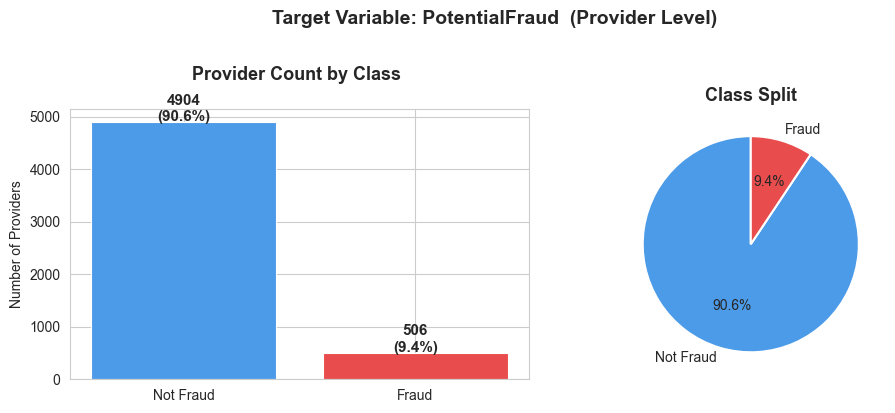

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Not Fraud", "Fraud"],
            [fraud_counts["No"], fraud_counts["Yes"]],
            color=["#4C9BE8", "#E84C4C"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Provider Count by Class \n", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Providers")

for i, (label, val) in enumerate(zip(["No", "Yes"], [fraud_counts["No"], fraud_counts["Yes"]])):
    axes[0].text(i, val + 20, f"{val}\n({fraud_pct[label]:.1f}%)",
                 ha="center", fontweight="bold", fontsize=11)

axes[1].pie([fraud_counts["No"], fraud_counts["Yes"]],
            labels=["Not Fraud", "Fraud"],
            colors=["#4C9BE8", "#E84C4C"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Class Split", fontsize=13, fontweight="bold")

plt.suptitle("Target Variable: PotentialFraud  (Provider Level)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

- The plot reveals a significant class imbalance:

  - 4,904 providers (90.6%) are labelled as Not Fraud
  - 506 providers (9.4%) are labelled as Fraud

This means for every 1 fraudulent provider, there are approximately 9.7 legitimate providers — a roughly 10:1 imbalance ratio.

---

In fraud detection, missing a fraudulent provider (False Negative) is far more costly than incorrectly flagging a legitimate one (False Positive). This means we will deliberately tune our model to maximise Recall, even at the cost of some Precision — a trade-off we will explore through threshold tuning.

## Beneficiary dataset

In [13]:
null_bene = benf_df.isnull().sum()
null_bene = null_bene[null_bene > 0]
print("Columns with nulls:")
print(null_bene)
print()
print("Sample rows:")
benf_df.head(3)

Columns with nulls:
DOD    137135
dtype: int64

Sample rows:


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40


In [14]:
print("Inpatient ClaimStartdate range:")
print("  Start:", inpatient_df["ClaimStartDt"].min(), "→", inpatient_df["ClaimStartDt"].max())
print("  End  :", inpatient_df["ClaimEndDt"].min(), "→", inpatient_df["ClaimEndDt"].max())

print("\nOutpatient ClaimStartDt range:")
print("  Start:", outpatient_df["ClaimStartDt"].min(), "→", outpatient_df["ClaimStartDt"].max())

print("\nBeneficiary DOB range:")
print(" ", benf_df["DOB"].min(), "→", benf_df["DOB"].max())

print("\nBeneficiary DOD (non-null):")
print(" ", benf_df["DOD"].dropna().min(), "→", benf_df["DOD"].dropna().max())

Inpatient ClaimStartdate range:
  Start: 2008-11-27 → 2009-12-31
  End  : 2009-01-01 → 2009-12-31

Outpatient ClaimStartDt range:
  Start: 2008-12-12 → 2009-12-31

Beneficiary DOB range:
  1909-01-01 → 1983-12-01

Beneficiary DOD (non-null):
  2009-02-01 → 2009-12-01


In [15]:
REF_DATE = max(inpatient_df["ClaimEndDt"].max(), outpatient_df["ClaimEndDt"].max())
REF_DATE = pd.to_datetime(REF_DATE)

benf_df["DOB"] = pd.to_datetime(benf_df["DOB"])
benf_df["DOD"] = pd.to_datetime(benf_df["DOD"], errors="coerce")

benf_df["Age"] = ((REF_DATE - benf_df["DOB"]).dt.days / 365.25).astype(int)
benf_df["IsDead"] = benf_df["DOD"].notna().astype(int)

In [16]:
benf_df[["DOB","DOD","Age","IsDead"]].head(20)

,DOB,DOD,Age,IsDead
0,1943-01-01,NaT,66,0
1,1936-09-01,NaT,73,0
2,1936-08-01,NaT,73,0
3,1922-07-01,NaT,87,0
4,1935-09-01,NaT,74,0
5,1976-09-01,NaT,33,0
6,1940-09-01,2009-12-01,69,1
7,1934-02-01,NaT,75,0
8,1929-06-01,NaT,80,0
9,1936-07-01,NaT,73,0


In [17]:
CHRONIC_COLS = [c for c in benf_df.columns if c.startswith("ChronicCond_")]
for col in CHRONIC_COLS:
    benf_df[col] = (benf_df[col] == 1).astype(int)

benf_df["ChronicCondCount"] = benf_df[CHRONIC_COLS].sum(axis=1)

In [18]:
benf_df.head(10)

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,IsDead,ChronicCondCount
0,BENE11001,1943-01-01,NaT,1,1,0,39,230,12,12,...,0,1,1,36000,3204,60,70,66,0,7
1,BENE11002,1936-09-01,NaT,2,1,0,39,280,12,12,...,0,0,0,0,0,30,50,73,0,0
2,BENE11003,1936-08-01,NaT,1,1,0,52,590,12,12,...,0,0,0,0,0,90,40,73,0,2
3,BENE11004,1922-07-01,NaT,1,1,0,39,270,12,12,...,1,1,0,0,0,1810,760,87,0,6
4,BENE11005,1935-09-01,NaT,1,1,0,24,680,12,12,...,0,0,0,0,0,1790,1200,74,0,2
5,BENE11006,1976-09-01,NaT,2,1,0,23,810,12,12,...,0,0,0,0,0,500,0,33,0,0
6,BENE11007,1940-09-01,2009-12-01,1,2,0,45,610,12,12,...,1,1,0,0,0,1490,160,69,1,5
7,BENE11008,1934-02-01,NaT,2,1,0,15,140,12,12,...,0,0,0,0,0,30,0,75,0,1
8,BENE11009,1929-06-01,NaT,1,1,Y,44,230,12,12,...,0,0,0,0,0,100,0,80,0,2
9,BENE11010,1936-07-01,NaT,2,1,0,41,30,12,12,...,1,0,0,0,0,1170,660,73,0,6


In [19]:
benf_df["RenalDiseaseIndicator"] = benf_df["RenalDiseaseIndicator"].map({'Y': 1, '0': 0})

print("Beneficiary cleaning done")
print(benf_df[["BeneID", "DOB", "Age", "IsDead", "ChronicCondCount"]].head(10))

Beneficiary cleaning done
      BeneID        DOB  Age  IsDead  ChronicCondCount
0  BENE11001 1943-01-01   66       0                 7
1  BENE11002 1936-09-01   73       0                 0
2  BENE11003 1936-08-01   73       0                 2
3  BENE11004 1922-07-01   87       0                 6
4  BENE11005 1935-09-01   74       0                 2
5  BENE11006 1976-09-01   33       0                 0
6  BENE11007 1940-09-01   69       1                 5
7  BENE11008 1934-02-01   75       0                 1
8  BENE11009 1929-06-01   80       0                 2
9  BENE11010 1936-07-01   73       0                 6


In [20]:
benf_df["Gender"] = (benf_df["Gender"] == 1).astype(int)

In [21]:
benf_df.head(20)

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,IsDead,ChronicCondCount
0,BENE11001,1943-01-01,NaT,1,1,0,39,230,12,12,...,0,1,1,36000,3204,60,70,66,0,7
1,BENE11002,1936-09-01,NaT,0,1,0,39,280,12,12,...,0,0,0,0,0,30,50,73,0,0
2,BENE11003,1936-08-01,NaT,1,1,0,52,590,12,12,...,0,0,0,0,0,90,40,73,0,2
3,BENE11004,1922-07-01,NaT,1,1,0,39,270,12,12,...,1,1,0,0,0,1810,760,87,0,6
4,BENE11005,1935-09-01,NaT,1,1,0,24,680,12,12,...,0,0,0,0,0,1790,1200,74,0,2
5,BENE11006,1976-09-01,NaT,0,1,0,23,810,12,12,...,0,0,0,0,0,500,0,33,0,0
6,BENE11007,1940-09-01,2009-12-01,1,2,0,45,610,12,12,...,1,1,0,0,0,1490,160,69,1,5
7,BENE11008,1934-02-01,NaT,0,1,0,15,140,12,12,...,0,0,0,0,0,30,0,75,0,1
8,BENE11009,1929-06-01,NaT,1,1,1,44,230,12,12,...,0,0,0,0,0,100,0,80,0,2
9,BENE11010,1936-07-01,NaT,0,1,0,41,30,12,12,...,1,0,0,0,0,1170,660,73,0,6


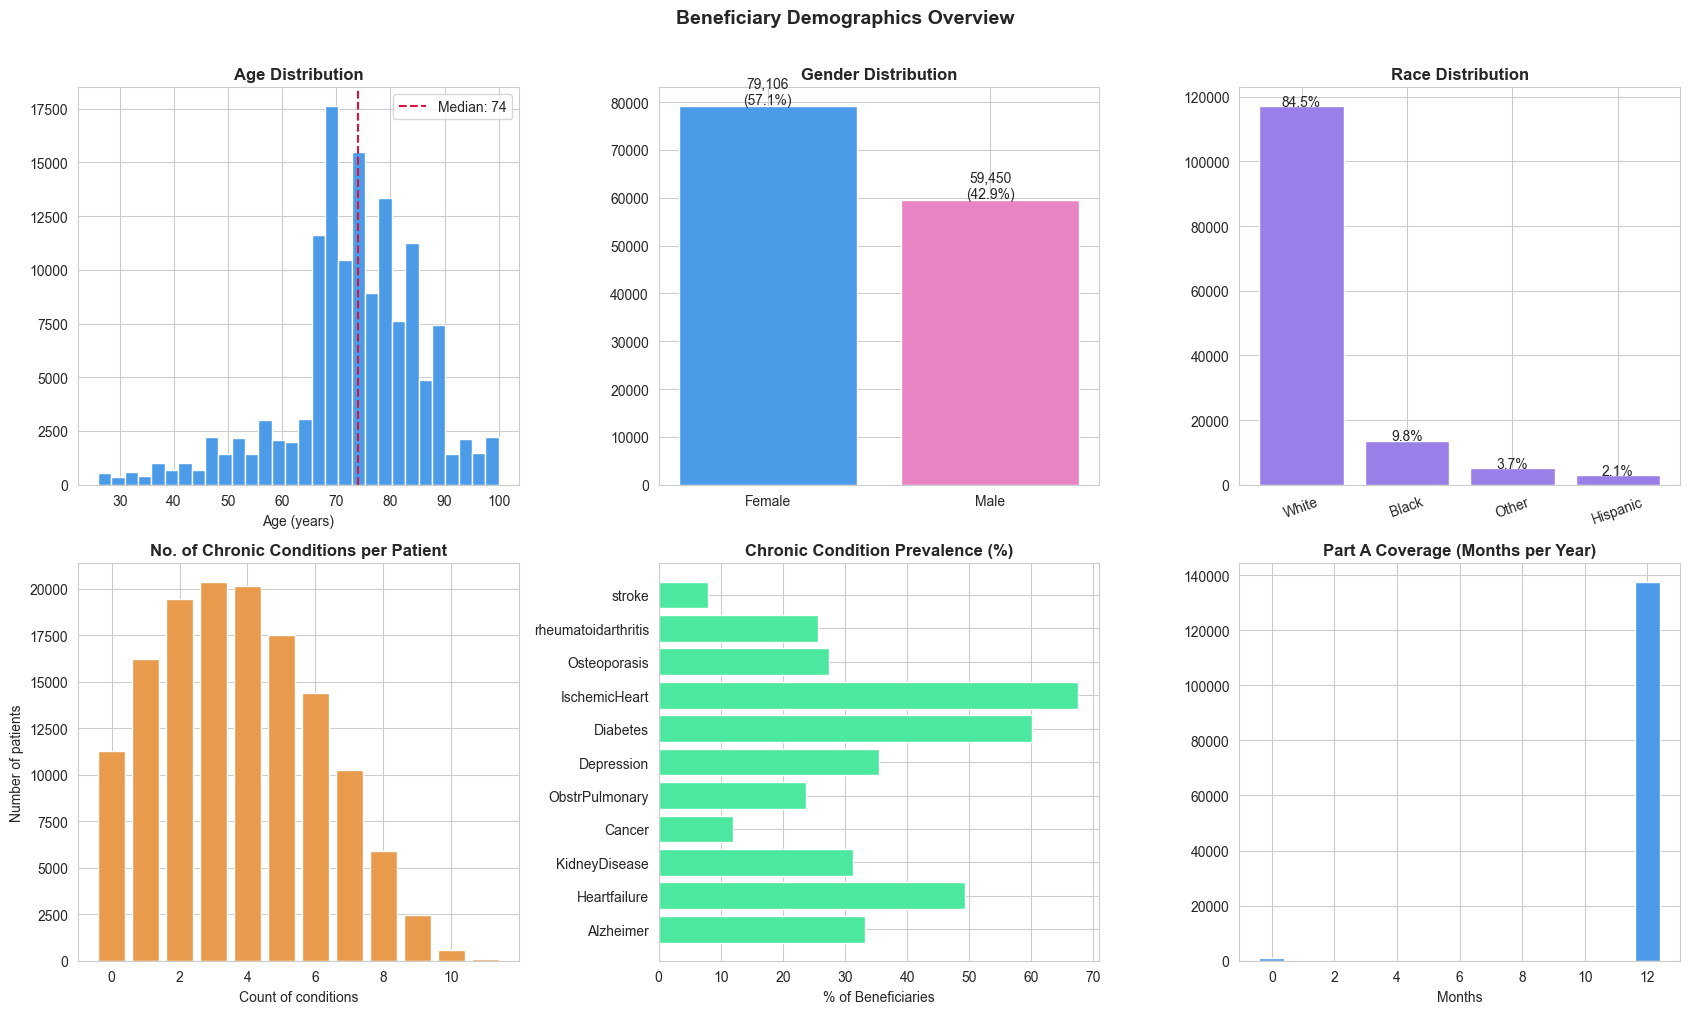

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

axes[0, 0].hist(benf_df["Age"], bins=30, color="#4C9BE8", edgecolor="white")
axes[0, 0].axvline(benf_df["Age"].median(), color="crimson",
                   linestyle="--", label=f"Median: {benf_df['Age'].median():.0f}")
axes[0, 0].set_title("Age Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Age (years)")
axes[0, 0].legend()

gender_map = {1: "Male", 0: "Female"}
gender_ct = benf_df["Gender"].map(gender_map).value_counts()
axes[0, 1].bar(gender_ct.index, gender_ct.values,
               color=["#4C9BE8", "#E884C4"], edgecolor="white")
axes[0, 1].set_title("Gender Distribution", fontweight="bold")
for i, v in enumerate(gender_ct.values):
    axes[0, 1].text(i, v + 400, f"{v:,}\n({v/len(benf_df)*100:.1f}%)",
                    ha="center", fontsize=10)

race_map = {1:"White", 2:"Black", 3:"Other", 5:"Hispanic"}
race_ct = benf_df["Race"].map(race_map).value_counts()
axes[0, 2].bar(race_ct.index, race_ct.values, color="#9B7FE8", edgecolor="white")
axes[0, 2].set_title("Race Distribution", fontweight="bold")
for i, v in enumerate(race_ct.values):
    axes[0, 2].text(i, v + 200, f"{v/len(benf_df)*100:.1f}%", ha="center", fontsize=10)
axes[0, 2].tick_params(axis="x", rotation=20)

cc_ct = benf_df["ChronicCondCount"].value_counts().sort_index()
axes[1, 0].bar(cc_ct.index, cc_ct.values, color="#E89B4C", edgecolor="white")
axes[1, 0].set_title("No. of Chronic Conditions per Patient", fontweight="bold")
axes[1, 0].set_xlabel("Count of conditions")
axes[1, 0].set_ylabel("Number of patients")

chron_pct = benf_df[CHRONIC_COLS].mean() * 100
chron_labels = [c.replace("ChronicCond_", "") for c in CHRONIC_COLS]
axes[1, 1].barh(chron_labels, chron_pct.values, color="#4CE8A0", edgecolor="white")
axes[1, 1].set_title("Chronic Condition Prevalence (%)", fontweight="bold")
axes[1, 1].set_xlabel("% of Beneficiaries")

part_a = benf_df["NoOfMonths_PartACov"].value_counts().sort_index()
axes[1, 2].bar(part_a.index, part_a.values, color="#4C9BE8", edgecolor="white")
axes[1, 2].set_title("Part A Coverage (Months per Year)", fontweight="bold")
axes[1, 2].set_xlabel("Months")

plt.suptitle("Beneficiary Demographics Overview", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

1. Age Distribution

The beneficiary population is concentrated between 65 and 85 years, with a median age of 74 years. This is expected — this is a Medicare dataset, which primarily covers individuals aged 65 and older. The small cluster of younger patients (below 60) likely represents individuals qualifying through disability. The right tail extending to 100+ indicates a meaningful elderly population, which is important because older patients typically have more complex and expensive medical needs.

<br>

2. Gender Distribution

The dataset has a slight female majority — 79,106 females (57.1%) vs 59,450 males (42.9%). This aligns with general Medicare demographics, as women on average have longer lifespans and therefore make up a larger share of the elderly insured population.

<br>

3. Race Distribution

The beneficiary pool is predominantly White (84.5%), followed by Black (9.8%), Other (3.7%), and Hispanic (2.1%). This demographic skew is worth noting as it reflects the underlying Medicare population composition, not a sampling bias.

<br>

4. Chronic Conditions per Patient

Most patients carry 3 to 5 chronic conditions simultaneously, with the distribution peaking around 4–5. Very few patients have zero chronic conditions, which makes sense given the elderly population. This high chronic condition burden directly drives high claim volumes and reimbursement amounts — making it a critical feature for distinguishing normal billing from fraud.

<br>

5. Chronic Condition Prevalence

Ischemic Heart Disease (~ 67%) and Diabetes (~ 62%) are by far the most prevalent conditions, affecting the majority of beneficiaries. Heart Failure (~ 48%) and Depression (~ 35%) follow. Stroke and Cancer are the least common. Fraudulent providers may disproportionately bill for high-reimbursement conditions like Ischemic Heart Disease, making these flags useful for fraud detection.

<br>

6. Part A Coverage

The vast majority of beneficiaries are covered for the full 12 months of the year, with almost no patients covered for fewer than 12 months. This means coverage duration adds very little discriminative power as a feature and can effectively be dropped or ignored during feature selection.

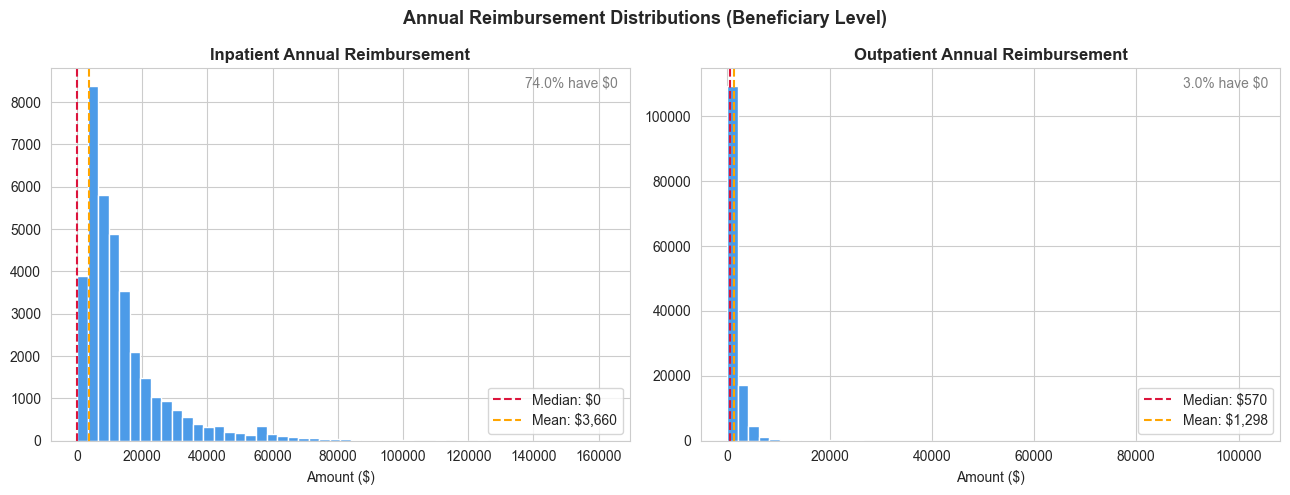

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "IPAnnualReimbursementAmt", "Inpatient Annual Reimbursement"),
    (axes[1], "OPAnnualReimbursementAmt", "Outpatient Annual Reimbursement")
]:
    data = benf_df[col]
    ax.hist(data[data > 0], bins=50, color="#4C9BE8", edgecolor="white")
    ax.axvline(data.median(), color="crimson", linestyle="--",
               label=f"Median: ${data.median():,.0f}")
    ax.axvline(data.mean(), color="orange", linestyle="--",
               label=f"Mean: ${data.mean():,.0f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Amount ($)")
    ax.legend()
    pct_zero = (data == 0).mean() * 100
    ax.text(0.98, 0.95, f"{pct_zero:.1f}% have $0",
            transform=ax.transAxes, ha="right", fontsize=10, color="gray")

plt.suptitle("Annual Reimbursement Distributions (Beneficiary Level)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Inpatient Annual Reimbursement

The inpatient distribution is extremely right-skewed with a striking split:

- 74% of beneficiaries have $0 inpatient reimbursement — meaning nearly three-quarters of patients had no hospital admissions at all during the year

- Among those who did have inpatient claims, reimbursements range widely from a few thousand dollars up to $160,000+

- The median is `$0` (pulled down by the majority with no inpatient claims), while the mean is $3,660 — a large gap that confirms the heavy skew

- Active claimants cluster between `$5,000`–`$20,000`, with a long tail extending all the way to `$160,000+` representing patients with multiple or very complex hospital admissions

This tells us inpatient care is expensive but rare — most patients never get admitted. A provider submitting unusually high inpatient volumes or reimbursements is therefore a strong fraud signal.

---

### Outpatient Annual Reimbursement
The outpatient picture is very different:

- Only 3% of beneficiaries have $0 outpatient reimbursement — meaning almost everyone uses outpatient services

- The distribution is again heavily right-skewed, with most patients clustering near $0 - $2,000

- The median is $570 and the mean is `$1,298`, a smaller gap than inpatient, reflecting more consistent low-cost usage

- A long right tail extends to $100,000+, representing patients with chronic conditions requiring frequent outpatient visits

Fraudulent providers may artificially convert outpatient visits into inpatient admissions to claim the higher reimbursement rates — a pattern known as upcoding

## Inpatient dataset

In [24]:
print("=" * 55)
print("INPATIENT DATASET  —  Null Analysis")
print("=" * 55)

null_inp = inpatient_df.isnull().sum()
null_pct = (null_inp / len(inpatient_df) * 100).round(1)
null_df = pd.DataFrame({"Missing": null_inp, "Missing%": null_pct})
null_df = null_df[null_df["Missing"] > 0].sort_values("Missing%", ascending=False)
print(null_df)
print()
print(f"Total rows: {len(inpatient_df):,}")

INPATIENT DATASET  —  Null Analysis
                     Missing  Missing%
ClmProcedureCode_6     40474     100.0
ClmProcedureCode_5     40465     100.0
ClmProcedureCode_4     40358      99.7
ClmProcedureCode_3     39509      97.6
ClmDiagnosisCode_10    36547      90.3
OtherPhysician         35784      88.4
ClmProcedureCode_2     35020      86.5
ClmProcedureCode_1     17326      42.8
OperatingPhysician     16644      41.1
ClmDiagnosisCode_9     13497      33.3
ClmDiagnosisCode_8      9942      24.6
ClmDiagnosisCode_7      7258      17.9
ClmDiagnosisCode_6      4838      12.0
ClmDiagnosisCode_5      2894       7.2
ClmDiagnosisCode_4      1534       3.8
DeductibleAmtPaid        899       2.2
ClmDiagnosisCode_3       676       1.7
ClmDiagnosisCode_2       226       0.6
AttendingPhysician       112       0.3

Total rows: 40,474


In [25]:
inpatient_df.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6'],
      dtype='object')

In [26]:
DATE_COLS_INP = ["ClaimStartDt", "ClaimEndDt", "AdmissionDt", "DischargeDt"]
for col in DATE_COLS_INP:
    inpatient_df[col] = pd.to_datetime(inpatient_df[col])

inpatient_df["ClaimDuration"] = (inpatient_df["ClaimEndDt"] - inpatient_df["ClaimStartDt"]).dt.days
inpatient_df["DaysInHospital"] = (inpatient_df["DischargeDt"] - inpatient_df["AdmissionDt"]).dt.days

In [27]:
inpatient_df.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'ClaimDuration', 'DaysInHospital'],
      dtype='object')

In [28]:
inpatient_df["ClaimDuration"] = inpatient_df["ClaimDuration"].clip(lower=0)
inpatient_df["DaysInHospital"] = inpatient_df["DaysInHospital"].clip(lower=0)

inpatient_df["DeductibleAmtPaid"] = inpatient_df["DeductibleAmtPaid"].fillna(0)

In [29]:
DIAG_COLS = [f"ClmDiagnosisCode_{i}" for i in range(1, 11)]
for col in DIAG_COLS:
    inpatient_df[col] = inpatient_df[col].fillna("NONE")

In [30]:
PROC_COLS = [f"ClmProcedureCode_{i}" for i in range(1, 7)]
for col in PROC_COLS:
    inpatient_df[col] = inpatient_df[col].fillna(0).astype(int).astype(str)
    inpatient_df[col] = inpatient_df[col].replace("0", "NONE")

In [31]:
inpatient_df["SameAttendOper"] = (
    inpatient_df["AttendingPhysician"].notna() &
    inpatient_df["OperatingPhysician"].notna() &
    (inpatient_df["AttendingPhysician"] == inpatient_df["OperatingPhysician"])
).astype(int)

In [32]:
print("Inpatient cleaning done")
print(inpatient_df[["ClaimID", "ClaimDuration", "DaysInHospital","DeductibleAmtPaid", "SameAttendOper"]].describe())

Inpatient cleaning done
       ClaimDuration  DaysInHospital  DeductibleAmtPaid  SameAttendOper
count   40474.000000    40474.000000       40474.000000    40474.000000
mean        5.660251        5.665168        1044.277808        0.163265
std         5.628873        5.638538         157.394952        0.369612
min         0.000000        0.000000           0.000000        0.000000
25%         2.000000        2.000000        1068.000000        0.000000
50%         4.000000        4.000000        1068.000000        0.000000
75%         7.000000        7.000000        1068.000000        0.000000
max        36.000000       35.000000        1068.000000        1.000000


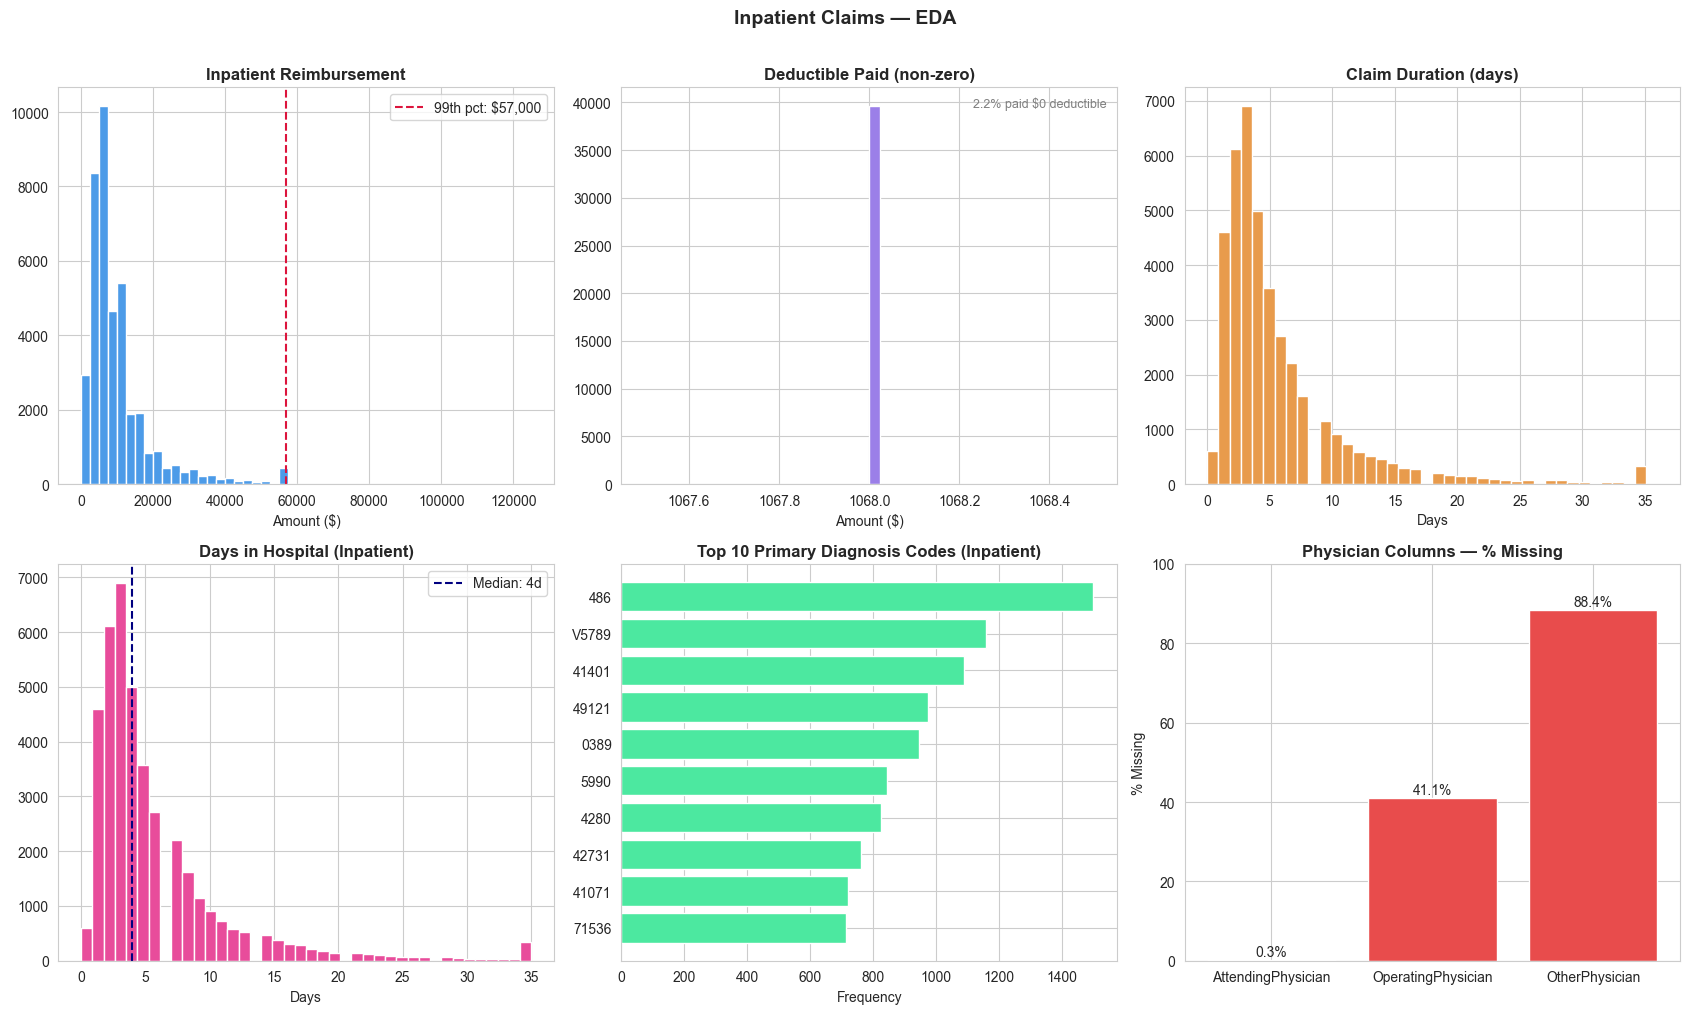

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

axes[0, 0].hist(inpatient_df["InscClaimAmtReimbursed"], bins=50,
                color="#4C9BE8", edgecolor="white")
axes[0, 0].set_title("Inpatient Reimbursement", fontweight="bold")
axes[0, 0].set_xlabel("Amount ($)")
q99 = inpatient_df["InscClaimAmtReimbursed"].quantile(0.99)
axes[0, 0].axvline(q99, color="crimson", linestyle="--",
                   label=f"99th pct: ${q99:,.0f}")
axes[0, 0].legend()

DeductibleAmtPaid_nz = inpatient_df.loc[inpatient_df["DeductibleAmtPaid"] > 0, "DeductibleAmtPaid"]
axes[0, 1].hist(DeductibleAmtPaid_nz, bins=40, color="#9B7FE8", edgecolor="white")
axes[0, 1].set_title("Deductible Paid (non-zero)", fontweight="bold")
axes[0, 1].set_xlabel("Amount ($)")
pct_zero_ded = (inpatient_df["DeductibleAmtPaid"] == 0).mean() * 100
axes[0, 1].text(0.98, 0.95, f"{pct_zero_ded:.1f}% paid $0 deductible",
                transform=axes[0, 1].transAxes, ha="right", fontsize=9, color="gray")

axes[0, 2].hist(inpatient_df["ClaimDuration"], bins=40, color="#E89B4C", edgecolor="white")
axes[0, 2].set_title("Claim Duration (days)", fontweight="bold")
axes[0, 2].set_xlabel("Days")

axes[1, 0].hist(inpatient_df["DaysInHospital"], bins=40, color="#E84C9B", edgecolor="white")
axes[1, 0].set_title("Days in Hospital (Inpatient)", fontweight="bold")
axes[1, 0].set_xlabel("Days")
axes[1, 0].axvline(inpatient_df["DaysInHospital"].median(), color="navy",
                   linestyle="--", label=f"Median: {inpatient_df['DaysInHospital'].median():.0f}d")
axes[1, 0].legend()

top_diag = inpatient_df["ClmDiagnosisCode_1"].value_counts().head(10)
axes[1, 1].barh(top_diag.index[::-1], top_diag.values[::-1],
                color="#4CE8A0", edgecolor="white")
axes[1, 1].set_title("Top 10 Primary Diagnosis Codes (Inpatient)", fontweight="bold")
axes[1, 1].set_xlabel("Frequency")

phys_miss = pd.Series({
    "AttendingPhysician": inpatient_df["AttendingPhysician"].isna().mean() * 100,
    "OperatingPhysician": inpatient_df["OperatingPhysician"].isna().mean() * 100,
    "OtherPhysician": inpatient_df["OtherPhysician"].isna().mean() * 100
})
axes[1, 2].bar(phys_miss.index, phys_miss.values, color="#E84C4C", edgecolor="white")
axes[1, 2].set_title("Physician Columns — % Missing", fontweight="bold")
axes[1, 2].set_ylabel("% Missing")
axes[1, 2].set_ylim(0, 100)

for i, v in enumerate(phys_miss.values):
    axes[1, 2].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

plt.suptitle("Inpatient Claims — EDA", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1. Inpatient Reimbursement
- The reimbursement amounts are heavily right-skewed. The majority of claims are reimbursed between `$0`–`$20,000`, with the distribution dropping sharply after that.
- The 99th percentile sits at `$57,000`, meaning only 1% of claims exceed this amount — but those extreme values can be very large (up to `$120,000+`). This skew is why we apply Winsorization at the 99th percentile before modelling, to prevent a handful of extreme claims from disproportionately influencing the model.

### 2. Deductible Paid (non-zero)
- This plot shows a striking anomaly — nearly all non-zero deductible payments are concentrated at exactly `$1,068`. This is not a data error; it reflects the fixed Medicare Part A deductible for inpatient hospital stays, which was `$1,068` in the dataset's reference year (2009).

- The note that 2.2% paid $0 deductible means most patients who were admitted did pay the standard deductible. This column has very low variance and will likely contribute little predictive power on its own.

### 3. Claim Duration (days)
- Most claims have a duration of 1–7 days, with the distribution peaking around 1–2 days and tapering off sharply.
- A small number of claims extend beyond 20–35 days, which could represent either legitimate long-term care or suspicious prolonged billing. The right tail is worth flagging — unusually long claim durations at the provider level are a known fraud indicator.

### 4. Days in Hospital (Inpatient)
- The median hospital stay is 4 days, which aligns with typical inpatient admission patterns. The distribution is right-skewed with most stays falling between 1–8 days.
- Stays extending beyond 15–20 days are rare and could represent either genuinely complex cases or inflated billing. At the provider level, average days in hospital will be one of our most important features — fraudulent providers tend to show systematically longer stays across their patient base.

### 5. Top 10 Primary Diagnosis Codes (Inpatient)
- Code 486 (Pneumonia) is the most frequently billed inpatient diagnosis by a significant margin, followed by V5789 (other aftercare), 41401 (Coronary artery disease), and 49121 (Obstructive chronic bronchitis).
- These codes represent high-cost, high-reimbursement conditions that are difficult to disprove without detailed clinical records — which is precisely why they are commonly associated with fraudulent billing. We will extract the top 100 diagnosis codes as binary provider-level features in our feature engineering step.

### 6. Physician Columns — % Missing
- The three physician columns show very different missingness patterns:

  - AttendingPhysician — 0.3% missing: Almost always recorded. Every inpatient admission should have a supervising physician, so this is expected.
  - OperatingPhysician — 41.1% missing: Not every admission involves a surgical procedure, so missing here is legitimate — it simply means no operation was performed.
  - OtherPhysician — 88.4% missing: Rarely recorded and mostly empty. This column will be dropped from the feature set as it adds almost no information.

## Outpatient dataset

In [34]:
outpatient_df.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
       'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
       'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
       'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1',
       'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4',
       'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid',
       'ClmAdmitDiagnosisCode'],
      dtype='object')

In [35]:
DATE_COLS_OUT = ["ClaimStartDt", "ClaimEndDt"]
for col in DATE_COLS_OUT:
    outpatient_df[col] = pd.to_datetime(outpatient_df[col])

outpatient_df["ClaimDuration"] = (outpatient_df["ClaimEndDt"] - outpatient_df["ClaimStartDt"]).dt.days
outpatient_df["ClaimDuration"] = outpatient_df["ClaimDuration"].clip(lower=0)

In [36]:
for col in DIAG_COLS:
    outpatient_df[col] = outpatient_df[col].fillna("NONE")

for col in PROC_COLS:
    outpatient_df[col] = outpatient_df[col].fillna(0).astype(int).astype(str)
    outpatient_df[col] = outpatient_df[col].replace("0", "NONE")

In [37]:
outpatient_df["ClmAdmitDiagnosisCode"] = outpatient_df["ClmAdmitDiagnosisCode"].fillna("NONE")

In [38]:
outpatient_df["SameAttendOper"] = (
    outpatient_df["AttendingPhysician"].notna() &
    outpatient_df["OperatingPhysician"].notna() &
    (outpatient_df["AttendingPhysician"] == outpatient_df["OperatingPhysician"])
).astype(int)

outpatient_df["DaysInHospital"] = 0

In [39]:
print("Outpatient cleaning done")
print(outpatient_df[["ClaimID", "ClaimDuration", "SameAttendOper"]].describe())

Outpatient cleaning done
       ClaimDuration  SameAttendOper
count  517737.000000   517737.000000
mean        1.420532        0.105374
std         4.707387        0.307035
min         0.000000        0.000000
25%         0.000000        0.000000
50%         0.000000        0.000000
75%         0.000000        0.000000
max        23.000000        1.000000


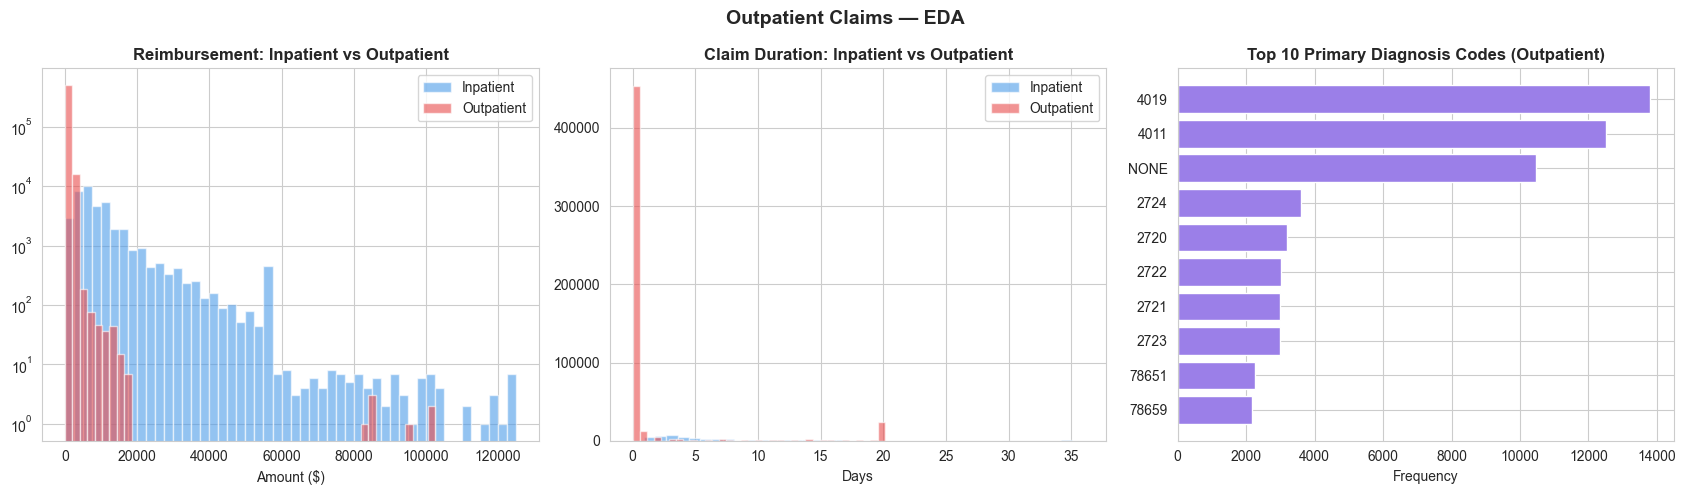

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].hist(inpatient_df["InscClaimAmtReimbursed"],  bins=50,
             alpha=0.6, color="#4C9BE8", edgecolor="white", label="Inpatient")
axes[0].hist(outpatient_df["InscClaimAmtReimbursed"], bins=50,
             alpha=0.6, color="#E84C4C", edgecolor="white", label="Outpatient")
axes[0].set_title("Reimbursement: Inpatient vs Outpatient",fontweight="bold")
axes[0].set_xlabel("Amount ($)")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].hist(inpatient_df["ClaimDuration"],  bins=40, alpha=0.6,
             color="#4C9BE8", label="Inpatient",  edgecolor="white")
axes[1].hist(outpatient_df["ClaimDuration"], bins=40, alpha=0.6,
             color="#E84C4C", label="Outpatient", edgecolor="white")
axes[1].set_title("Claim Duration: Inpatient vs Outpatient", fontweight="bold")
axes[1].set_xlabel("Days")
axes[1].legend()

top_out_diag = outpatient_df["ClmDiagnosisCode_1"].value_counts().head(10)
axes[2].barh(top_out_diag.index[::-1], top_out_diag.values[::-1],
             color="#9B7FE8", edgecolor="white")
axes[2].set_title("Top 10 Primary Diagnosis Codes (Outpatient)", fontweight="bold")
axes[2].set_xlabel("Frequency")

plt.suptitle("Outpatient Claims — EDA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 1. Reimbursement: Inpatient vs Outpatient (Log Scale)
- The y-axis is on a log scale, which is necessary because the count difference between inpatient and outpatient claims is enormous — outpatient has 517,737 claims vs inpatient's 40,474. Key observations:

  - Outpatient reimbursements are concentrated at very low amounts (`$0`–`$5,000`), reflecting the nature of day visits, check-ups, and minor procedures
  - Inpatient reimbursements are spread across a much wider range (`$5,000`–`$120,000+`), consistent with expensive hospital stays
  - This difference is critical for fraud detection: a provider billing outpatient visits at inpatient-level amounts is an immediate red flag


### 2. Claim Duration: Inpatient vs Outpatient

- Outpatient claims are almost exclusively 0–1 days — the massive spike at day 0 represents same-day visits where the claim start and end date are identical
- Inpatient claims spread across 1–35+ days, reflecting actual hospital stays
- The single outpatient spike at day 20 is suspicious and worth investigating — it could represent a data entry error or a batch of claims that were incorrectly filed as outpatient when they should have been inpatient
- ClaimDuration will behave very differently for inpatient vs outpatient, which is why keeping the ClaimType flag and computing separate averages per type at provider level matters


### 3. Top 10 Primary Diagnosis Codes (Outpatient)
The outpatient diagnosis code landscape is very different from inpatient:

- 4019 (Hypertension, unspecified) and 4011 (Benign essential hypertension) dominate — these are chronic conditions managed through regular outpatient visits, explaining their high frequency
- NONE appearing as the third most common entry confirms that a large number of outpatient claims have no primary diagnosis code recorded — this is a data quality issue specific to the outpatient dataset (10,453 missing values in ClmDiagnosisCode_1)
- Codes 2724, 2720, 2721, 2722, 2723 are all related to disorders of lipid metabolism (cholesterol conditions) — again chronic conditions managed outpatient
- 78651 and 78659 relate to chest pain — high-frequency outpatient presentations

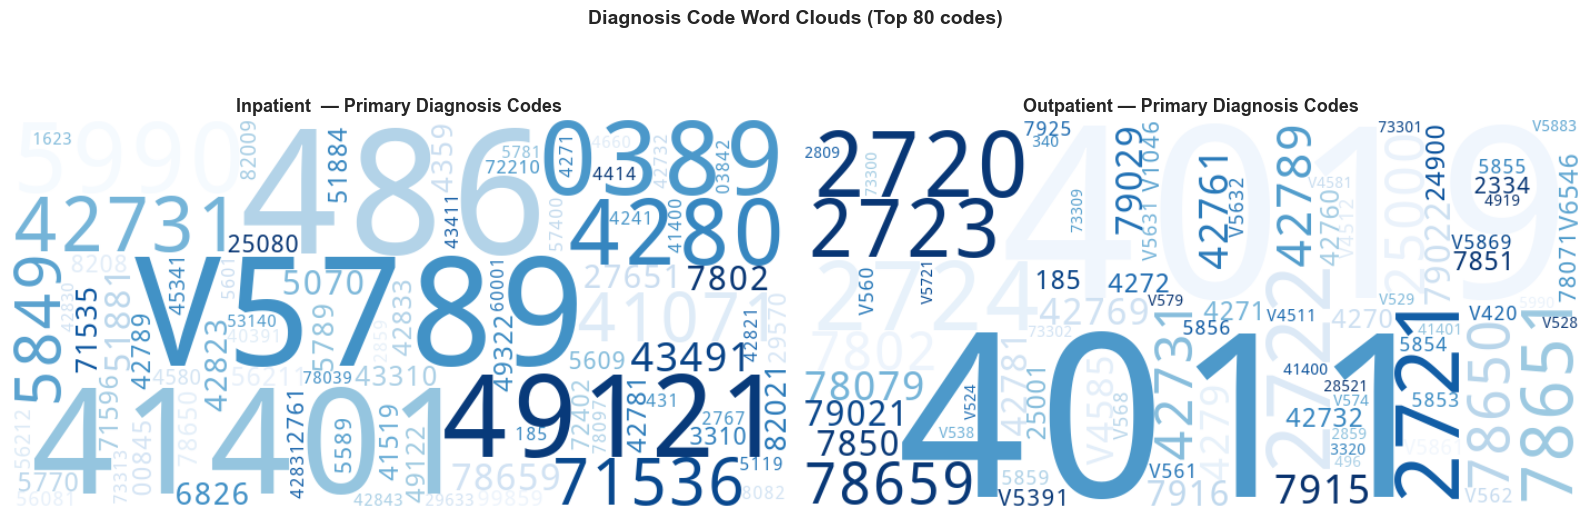

In [41]:
def make_wordcloud(series, title, ax, max_words=80):
    freq = series[series != "NONE"].value_counts().head(max_words).to_dict()
    wc = WordCloud(width=700, height=350, background_color="white",
                   colormap="Blues", max_words=max_words)
    wc.generate_from_frequencies(freq)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontweight="bold", fontsize=13)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
make_wordcloud(inpatient_df["ClmDiagnosisCode_1"], "Inpatient  — Primary Diagnosis Codes", axes[0])
make_wordcloud(outpatient_df["ClmDiagnosisCode_1"], "Outpatient — Primary Diagnosis Codes", axes[1])
plt.suptitle("Diagnosis Code Word Clouds (Top 80 codes)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()